
First 5 rows:
   alcohol  malic_acid   ash  alcalinity_of_ash  magnesium  total_phenols  \
0    14.23        1.71  2.43               15.6      127.0           2.80   
1    13.20        1.78  2.14               11.2      100.0           2.65   
2    13.16        2.36  2.67               18.6      101.0           2.80   
3    14.37        1.95  2.50               16.8      113.0           3.85   
4    13.24        2.59  2.87               21.0      118.0           2.80   

   flavanoids  nonflavanoid_phenols  proanthocyanins  color_intensity   hue  \
0        3.06                  0.28             2.29             5.64  1.04   
1        2.76                  0.26             1.28             4.38  1.05   
2        3.24                  0.30             2.81             5.68  1.03   
3        3.49                  0.24             2.18             7.80  0.86   
4        2.69                  0.39             1.82             4.32  1.04   

   od280/od315_of_diluted_wines  proline  targe

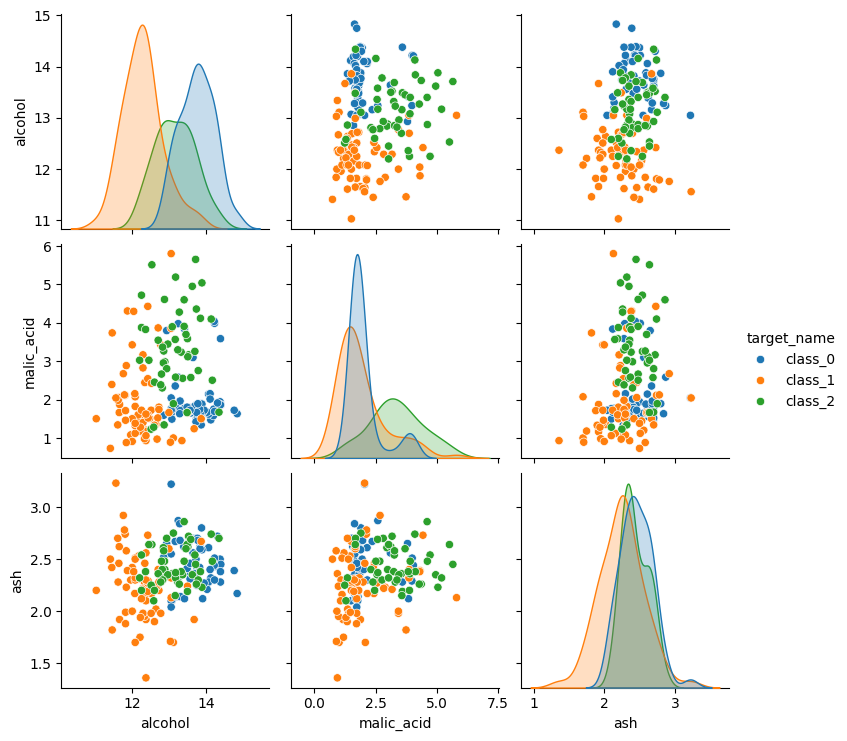

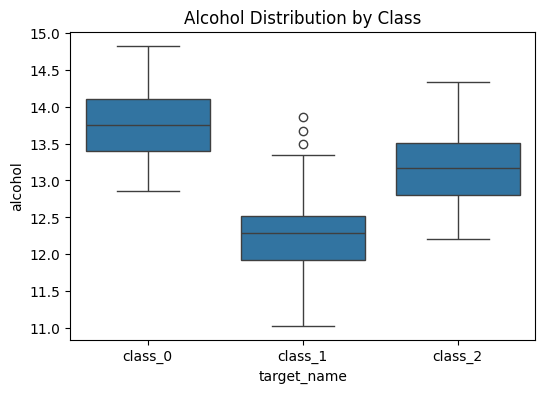


Model Accuracy: 0.9166666666666666

Classification Report:
              precision    recall  f1-score   support

           0       0.93      1.00      0.97        14
           1       0.87      0.93      0.90        14
           2       1.00      0.75      0.86         8

    accuracy                           0.92        36
   macro avg       0.93      0.89      0.91        36
weighted avg       0.92      0.92      0.91        36



In [1]:
# ============================================================
# WINE DATASET
# Classification using Regression Model
# ============================================================

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import accuracy_score, classification_report
import numpy as np

# ============================================================
# 1. LOAD & EXPLORE THE DATASET
# ============================================================

wine = load_wine()

# Convert to DataFrame
df = pd.DataFrame(wine.data, columns=wine.feature_names)
df["target"] = wine.target

# Map integers to class names
class_map = {0: "class_0", 1: "class_1", 2: "class_2"}
df["target_name"] = df["target"].map(class_map)

print("\nFirst 5 rows:")
print(df.head())

print("\nDataset Overview:")
print(df.describe())

print("\nClass Counts:")
print(df["target_name"].value_counts())

# ============================================================
# 2. SPLIT DATA
# ============================================================

X = df.drop(["target", "target_name"], axis=1)
y = df["target"]

# Handle missing values (Wine dataset has none, but we include the step)
X = X.fillna(X.mean())

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ============================================================
# 3. DATA VISUALIZATION
# ============================================================

# Pairplot (small subset to avoid heavy plotting)
sns.pairplot(df[["alcohol", "malic_acid", "ash", "target_name"]],
             hue="target_name")
plt.show()

# Boxplot of alcohol by class
plt.figure(figsize=(6, 4))
sns.boxplot(x="target_name", y="alcohol", data=df)
plt.title("Alcohol Distribution by Class")
plt.show()

# ============================================================
# 4. MODEL BUILDING (Regression used for Classification)
# ============================================================

# Train a regression model
model = LinearRegression()
model.fit(X_train_scaled, y_train)

# Predict continuous values
y_pred_continuous = model.predict(X_test_scaled)

# Convert regression output to class labels
y_pred = np.round(y_pred_continuous).astype(int)

# Clip values to valid class range
y_pred = np.clip(y_pred, 0, 2)

# ============================================================
# 5. MODEL EVALUATION
# ============================================================

accuracy = accuracy_score(y_test, y_pred)
print("\nModel Accuracy:", accuracy)

print("\nClassification Report:")
print(classification_report(y_test, y_pred, zero_division=0))